# Options Price Grid (Rounds 3 & 4)

Plot every `VEV_*` options contract on one grid per round using historical mid prices.

In [1]:
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "data").is_dir() and (candidate / "assets").is_dir():
            return candidate
    raise FileNotFoundError("Could not find repo root (expected data/ and assets/)")


ROOT = find_repo_root(Path.cwd().resolve())
ROUNDS = [3, 4]
TIMESTAMPS_PER_DAY = 1_000_000


def round_paths(round_num: int) -> tuple[Path, Path]:
    round_dir = ROOT / "data" / f"Round-{round_num}"
    out_dir = ROOT / "assets" / "historical_prices" / f"Round-{round_num}"
    out_dir.mkdir(parents=True, exist_ok=True)
    return round_dir, out_dir


In [2]:
def load_round(round_dir: Path) -> pd.DataFrame:
    files = sorted(
        round_dir.glob("prices_round_*_day_*.csv"),
        key=lambda p: int(re.search(r"day_(-?\d+)", p.stem).group(1)),
    )
    if not files:
        raise FileNotFoundError(f"No price CSVs found in {round_dir}")

    frames = []
    days_seen = []
    for f in files:
        df = pd.read_csv(f, sep=";")
        days_seen.append(int(df["day"].iloc[0]))
        frames.append(df)

    combined = pd.concat(frames, ignore_index=True)
    day_order = {d: i for i, d in enumerate(sorted(set(days_seen)))}
    combined["global_t"] = (
        combined["day"].map(day_order) * TIMESTAMPS_PER_DAY + combined["timestamp"]
    )
    return combined.sort_values(["product", "global_t"]).reset_index(drop=True)


def clean_mid_prices(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    both = df["bid_price_1"].notna() & df["ask_price_1"].notna()
    df.loc[both, "mid_price"] = (
        df.loc[both, "bid_price_1"] + df.loc[both, "ask_price_1"]
    ) / 2

    one_side = ~both
    df.loc[one_side, "mid_price"] = df.loc[one_side, "bid_price_1"].fillna(
        df.loc[one_side, "ask_price_1"]
    )
    df = df.dropna(subset=["mid_price"])
    return df[df["mid_price"] > 0]


def option_strike(product: str) -> int:
    return int(product.split("_")[1])


In [3]:
def plot_options_grid(round_num: int) -> None:
    round_dir, out_dir = round_paths(round_num)
    df = clean_mid_prices(load_round(round_dir))
    options = df[df["product"].str.match(r"^VEV_\d+$")].copy()
    products = sorted(options["product"].unique(), key=option_strike)
    days = sorted(options["day"].unique())

    print(f"Round {round_num} option contracts: {len(products)}")
    print(products)

    cols = 3
    rows = math.ceil(len(products) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(17, rows * 3.2), sharex=True)
    axes = axes.flatten()

    for ax, product in zip(axes, products):
        sub = options[options["product"] == product]
        ax.plot(sub["global_t"], sub["mid_price"], linewidth=0.8)

        for i, _day in enumerate(days):
            if i > 0:
                ax.axvline(i * TIMESTAMPS_PER_DAY, color="grey", alpha=0.3, linestyle="--")

        ax.set_title(product)
        ax.set_ylabel("mid price")
        ax.grid(True, alpha=0.3)

    for ax in axes[len(products):]:
        ax.axis("off")

    for ax in axes[: len(products)]:
        ax.set_xticks([(i + 0.5) * TIMESTAMPS_PER_DAY for i in range(len(days))])
        ax.set_xticklabels([f"day {day}" for day in days])

    fig.suptitle(
        f"Round {round_num} Options Contracts Historical Mid Prices",
        fontsize=16,
        y=1.0,
    )
    fig.tight_layout()
    out_path = out_dir / "COMBINED_VOUCHERS.png"
    fig.savefig(out_path, dpi=120, bbox_inches="tight")
    print(f"Saved to {out_path.relative_to(ROOT)}")
    plt.show()


Round 3 option contracts: 10
['VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']
Saved to assets/historical_prices/Round-3/COMBINED_VOUCHERS.png


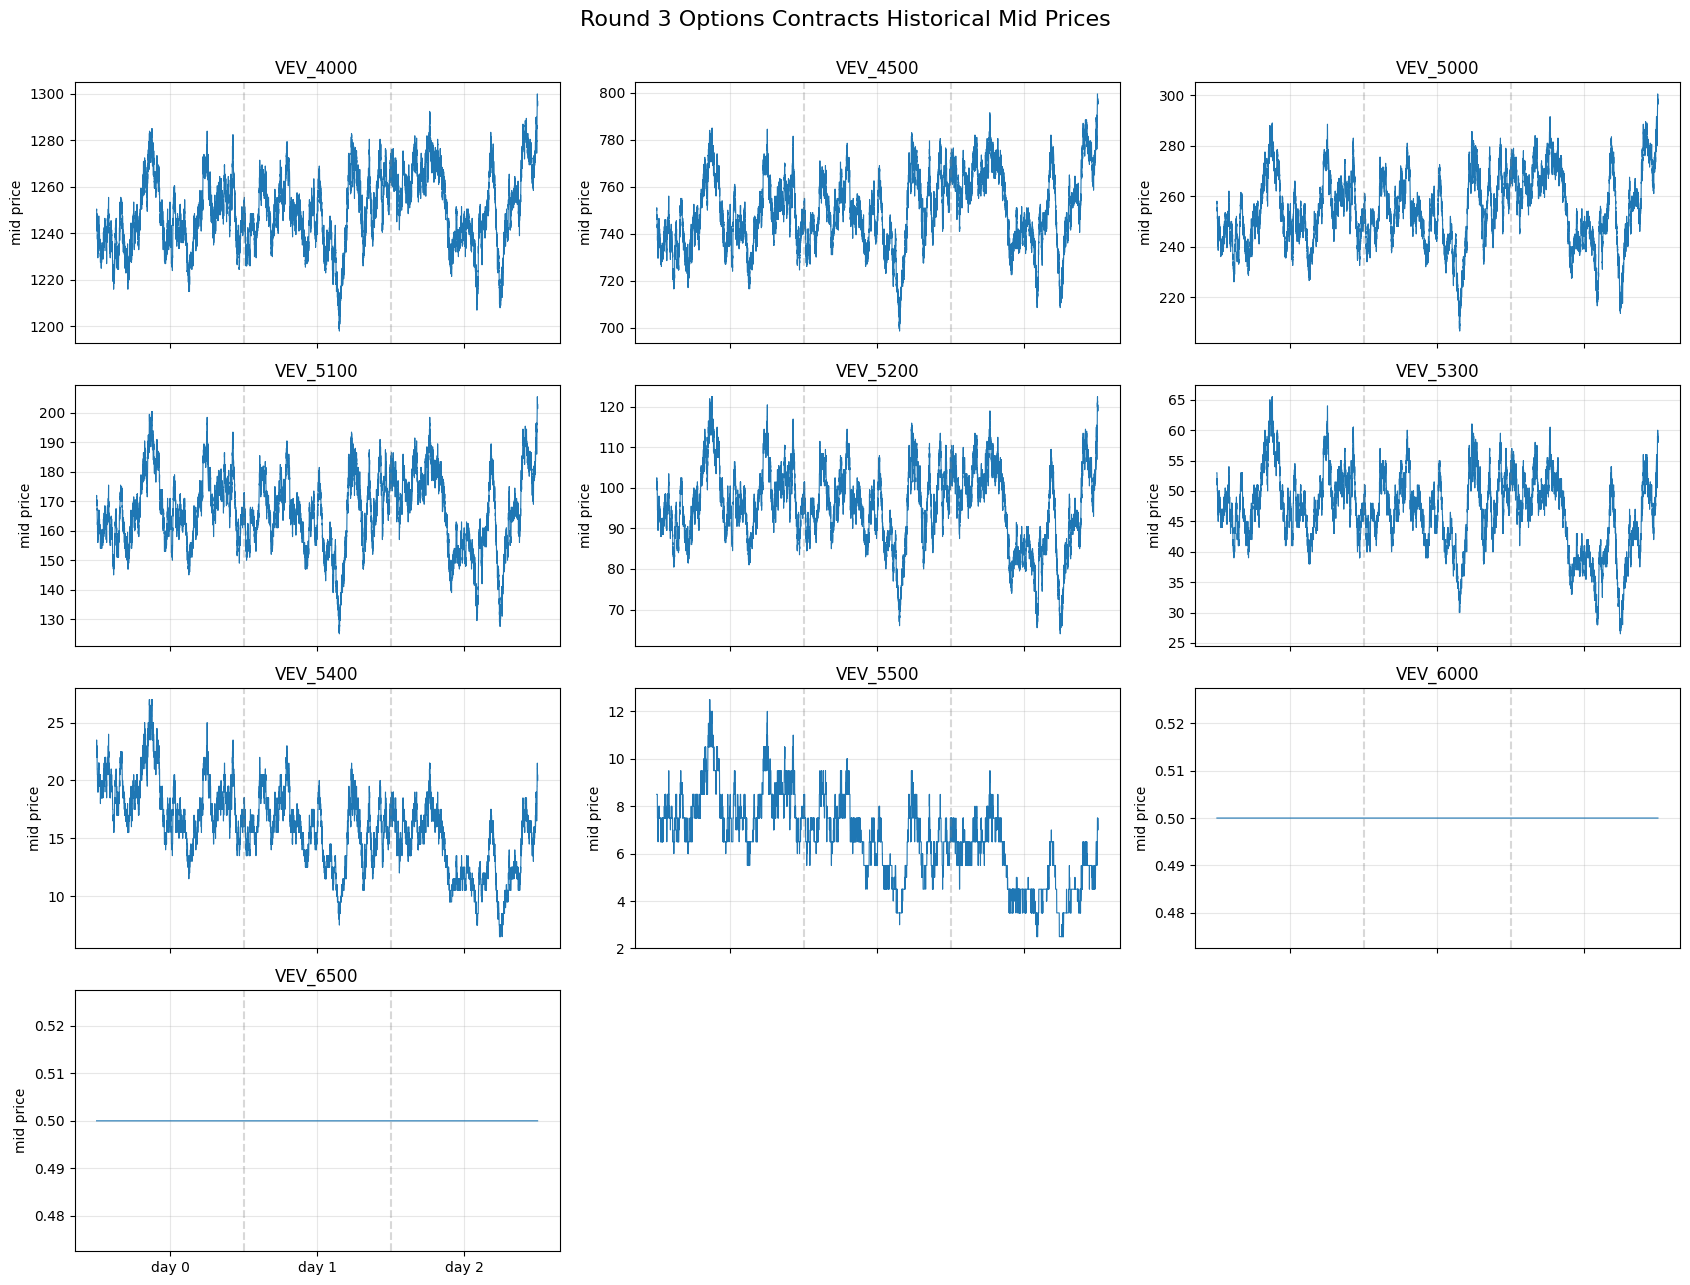

Round 4 option contracts: 10
['VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']
Saved to assets/historical_prices/Round-4/COMBINED_VOUCHERS.png


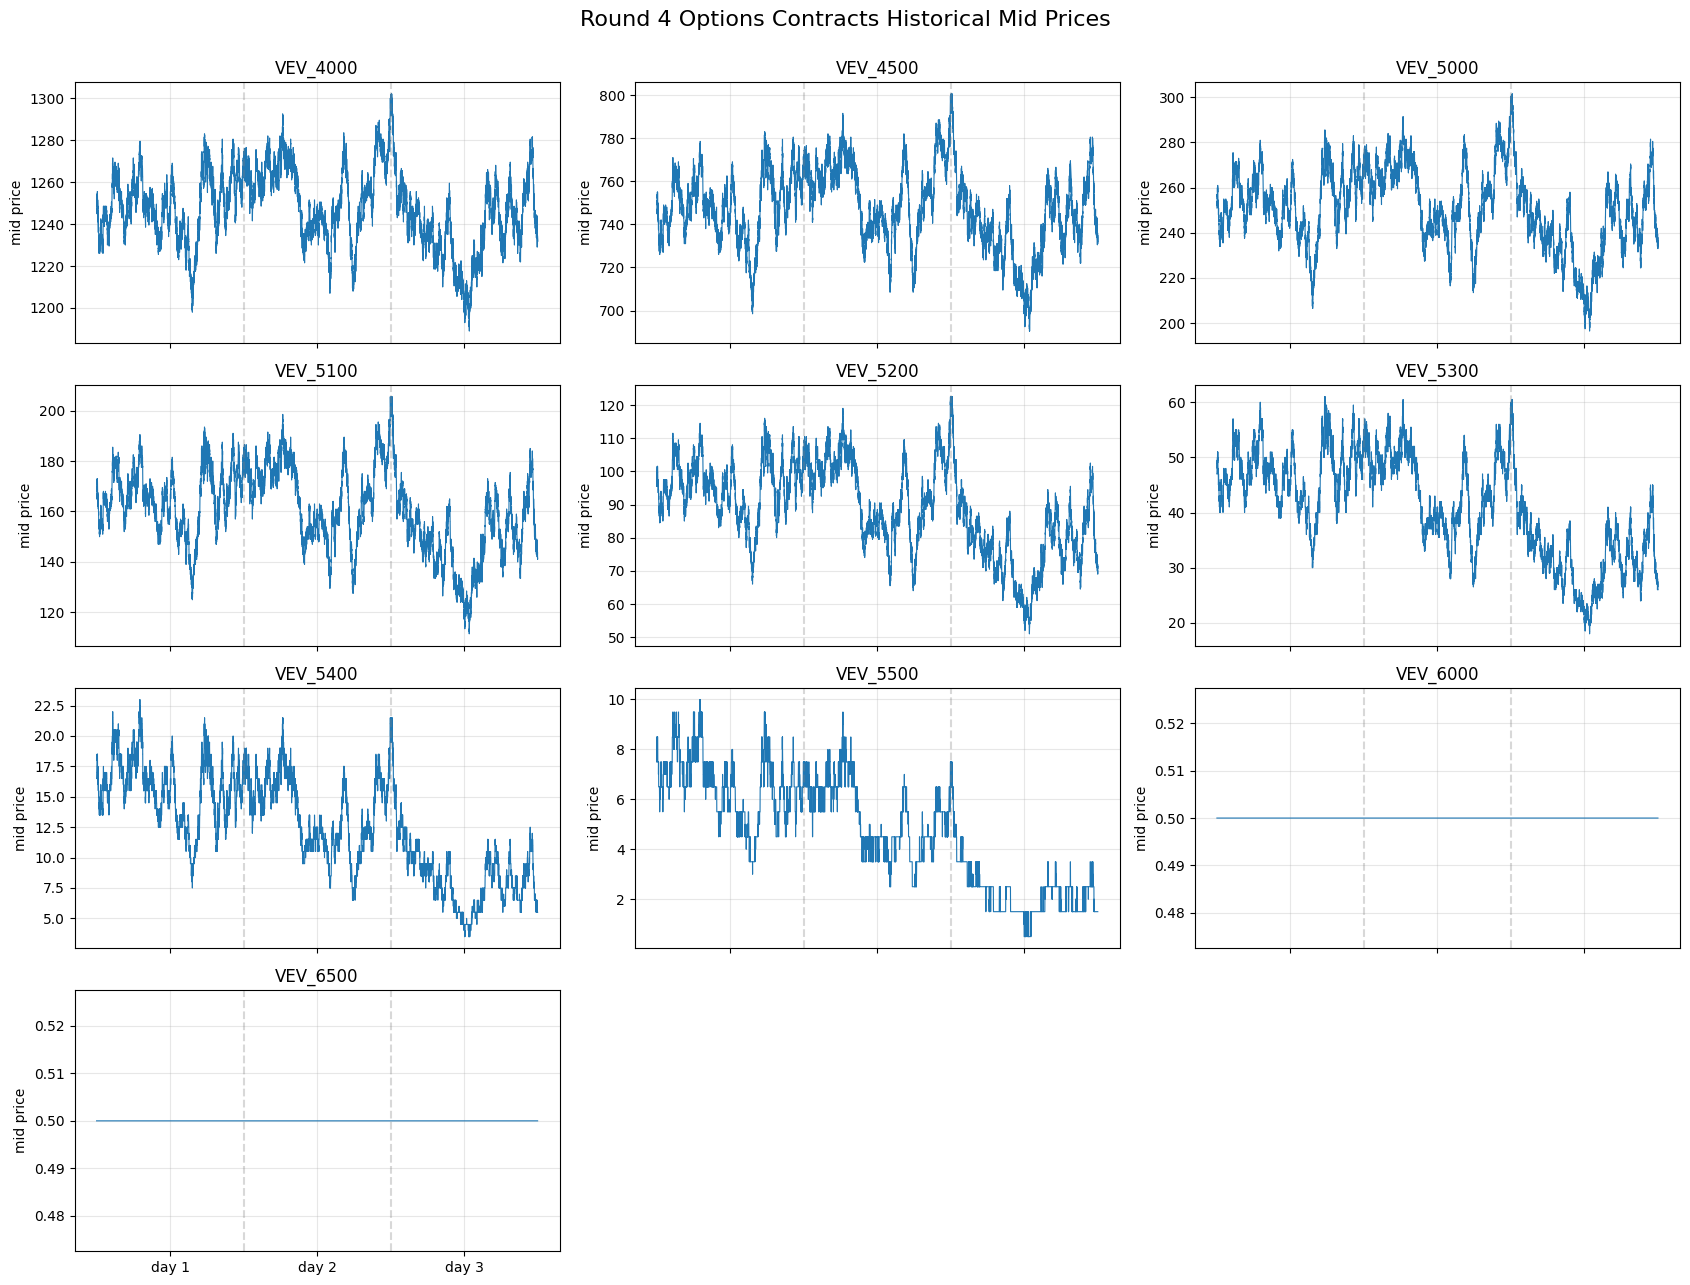

In [4]:
for round_num in ROUNDS:
    plot_options_grid(round_num)
